In [3]:
# !pip install scikit-learn==1.3.2 imbalanced-learn==0.11.0

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from collections import Counter
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import (classification_report, confusion_matrix, average_precision_score, PrecisionRecallDisplay, precision_recall_curve, 
                             roc_auc_score, recall_score, cohen_kappa_score)

In [5]:
# =====================
# 1. Prepare Data
# =====================
df = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local
df.head(2)

X = df.drop(columns=['status'])
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

# print("Before SMOTE:", Counter(y_train))
# print("After SMOTE:", Counter(y_train_sm))

## Base Model

In [6]:
# =====================
# 2. Base Model with SMOTE outside pipeline
# =====================
base_lr = LogisticRegression(solver='liblinear', random_state=42)
base_lr.fit(X_train_sm, y_train_sm)

y_pred_base = base_lr.predict(X_test)
y_proba_base = base_lr.predict_proba(X_test)[:, 1]
y_train_pred_base = base_lr.predict(X_train_sm)

# Evaluation
print(confusion_matrix(y_test, y_pred_base))
print("------------------------------------------------------")
print(classification_report(y_test, y_pred_base, digits=3))
print("------------------------------------------------------")
print(f"Test Average Precision: {average_precision_score(y_test, y_proba_base):.3f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_base):.3f}")
print(f"Test Cohen's Kappa: {cohen_kappa_score(y_test, y_pred_base):.3f}")
print(f"Training recall: {recall_score(y_train_sm, y_train_pred_base):.3f}")

[[522 185]
 [155 449]]
------------------------------------------------------
              precision    recall  f1-score   support

           0      0.771     0.738     0.754       707
           1      0.708     0.743     0.725       604

    accuracy                          0.741      1311
   macro avg      0.740     0.741     0.740      1311
weighted avg      0.742     0.741     0.741      1311

------------------------------------------------------
Test Average Precision: 0.761
Test AUC: 0.795
Test Cohen's Kappa: 0.480
Training recall: 0.744


## Tuned Model

In [7]:
# Define pipeline
pipe = Pipeline([
    # ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('smote', SMOTE(random_state=42)),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])

# Define full parameter grid (including solver and penalty)
param_grid = [
    {
        'lr__penalty': ['l1'],
        'lr__solver': ['liblinear', 'saga'],
        'lr__C': [0.01, 0.1, 1, 10]
    },
    {
        'lr__penalty': ['l2'],
        'lr__solver': ['lbfgs', 'liblinear', 'saga'],
        'lr__C': [0.01, 0.1, 1, 10]
    },
    {
        'lr__penalty': ['elasticnet'],
        'lr__solver': ['saga'],
        'lr__C': [0.01, 0.1, 1, 10],
        'lr__l1_ratio': [0.1, 0.5, 0.9]  # Only relevant for elasticnet
    }
]

# Run GridSearchCV
grid_lr = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='recall',
    cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
,
    verbose=2,
    n_jobs=-1
)

# Fit the model
grid_lr.fit(X_train, y_train)

# Predict and evaluate
best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test)
y_proba_tune = best_lr.predict_proba(X_test)[:, 1]

# Print best parameters and evaluation
print("\n--- Logistic Regression Performance ---")
print("Best Parameters:", grid_lr.best_params_)
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, digits=3))

y_train_pred_lr = best_lr.predict(X_train)

print('------------------------------------------------------')
print(f"Training recall: {recall_score(y_train, y_train_pred_lr):.3f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_tune):.3f}")
print(f"Test Avg Precision: {average_precision_score(y_test, y_proba_tune):.3f}")
print(f"Test Cohen's Kappa: {cohen_kappa_score(y_test, y_pred_lr):.3f}")


Fitting 15 folds for each of 32 candidates, totalling 480 fits

--- Logistic Regression Performance ---
Best Parameters: {'lr__C': 0.01, 'lr__penalty': 'l1', 'lr__solver': 'liblinear'}
[[433 274]
 [161 443]]
              precision    recall  f1-score   support

           0      0.729     0.612     0.666       707
           1      0.618     0.733     0.671       604

    accuracy                          0.668      1311
   macro avg      0.673     0.673     0.668      1311
weighted avg      0.678     0.668     0.668      1311

------------------------------------------------------
Training recall: 0.748
Test AUC: 0.747
Test Avg Precision: 0.707
Test Cohen's Kappa: 0.341


### 95% CI on Recall

Recall 95% CI: (0.707, 0.778)


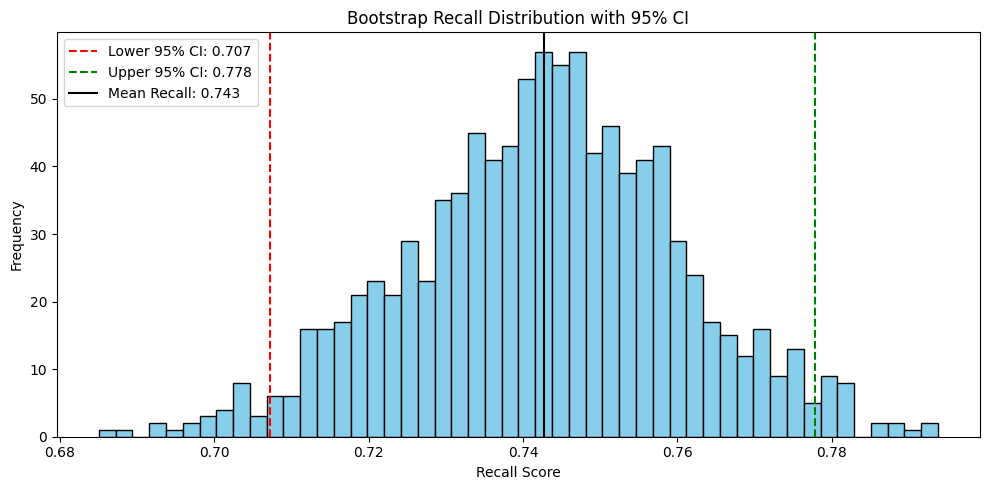

In [8]:
def bootstrap_ci_recall_distribution(y_true, y_pred_func, X, n_bootstraps=1000, alpha=0.95):
    rng = np.random.RandomState(42)
    bootstrapped_scores = []
    n = len(y_true)
    for _ in range(n_bootstraps):
        indices = rng.choice(np.arange(n), size=n, replace=True)
        if len(np.unique(y_true.iloc[indices])) < 2:
            continue
        score = recall_score(y_true.iloc[indices], y_pred_func(X.iloc[indices]))
        bootstrapped_scores.append(score)
    sorted_scores = np.sort(bootstrapped_scores)
    lower = np.percentile(sorted_scores, ((1-alpha)/2)*100)
    upper = np.percentile(sorted_scores, (alpha + (1-alpha)/2)*100)
    return bootstrapped_scores, lower, upper

# scores
recall_scores, lower_ci, upper_ci = bootstrap_ci_recall_distribution(
    y_test.reset_index(drop=True), 
    base_lr.predict,  #calculated on base model because base model is better than tuned model
    X_test.reset_index(drop=True)
)

print(f"Recall 95% CI: ({lower_ci:.3f}, {upper_ci:.3f})")

# plot
plt.figure(figsize=(10, 5))
plt.hist(recall_scores, bins=50, color='skyblue', edgecolor='black')
plt.axvline(lower_ci, color='red', linestyle='--', label=f"Lower 95% CI: {lower_ci:.3f}")
plt.axvline(upper_ci, color='green', linestyle='--', label=f"Upper 95% CI: {upper_ci:.3f}")
plt.axvline(np.mean(recall_scores), color='black', linestyle='-', label=f"Mean Recall: {np.mean(recall_scores):.3f}")
plt.title("Bootstrap Recall Distribution with 95% CI")
plt.xlabel("Recall Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

### Feature importance

Logistic Regression naturally supports feature importance because it is a linear model. The model coefficients (coef_) can be interpreted as the impact of each feature on the log-odds of the positive class.

                            Feature      Base     Tuned
0                         child_age  1.188898  0.403934
1                      child_weight -1.998074 -0.874840
2            diarrhoea_last_2_weeks  0.012491  0.000000
3                fever_last_2_weeks -0.137660  0.000000
4                              area -0.165644  0.000000
5                         child_sex  0.466503  0.000000
6                  mother_education -0.129420 -0.219908
7                  health_insurance  0.214744  0.000000
8                      wealth_index -0.085455 -0.199188
9         province_Gandaki Province -0.189544  0.000000
10        province_Karnali Province  0.239506  0.000000
11              province_Province 1 -0.227049  0.000000
12              province_Province 2  0.246789  0.000000
13              province_Province 5 -0.011794  0.000000
14  province_Sudoorpaschim Province  0.052835  0.000000


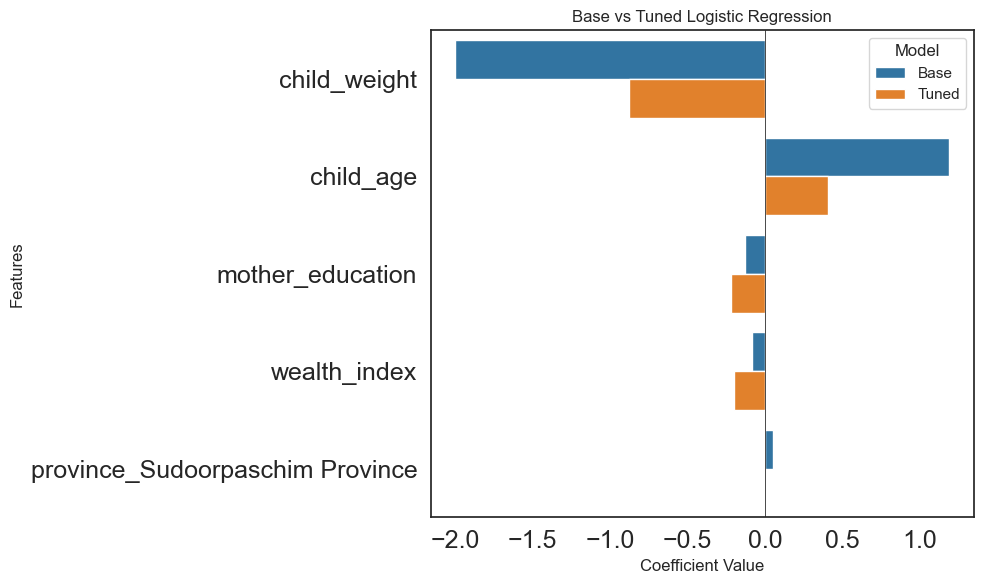

In [43]:
# Extract absolute coefficients
coef_base = base_lr.coef_[0]
coef_tuned = best_lr.named_steps['lr'].coef_[0]

# Combine and melt data for seaborn
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Base': coef_base,
    'Tuned': coef_tuned
})

# Melt for long format
melted_df = importance_df.melt(id_vars='Feature', var_name='Model', value_name='Coefficient')

# Take top 10 features based on absolute tuned coefficients
top_features = importance_df.loc[np.abs(importance_df['Tuned']).argsort()[-5:]]['Feature'].tolist()
melted_df = melted_df[melted_df['Feature'].isin(top_features)]

# Sort by mean of absolute coefficient (so order is consistent)
feature_order = (melted_df.groupby('Feature')['Coefficient']
                 .apply(lambda x: np.abs(x).mean())
                 .sort_values(ascending=False)).index

print(importance_df)

# Plot
sns.set_style("white")
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=melted_df,
    y='Feature',
    x='Coefficient',
    hue='Model',
    order=feature_order,
    palette=['#1f77b4', '#ff7f0e']
)

# Add titles and labels
plt.title('Base vs Tuned Logistic Regression')
plt.xlabel('Coefficient Value', fontsize=12)
plt.axvline(x=0, color='black', linewidth=0.5)
plt.ylabel('Features')
plt.yticks(fontsize=18) 
plt.xticks(fontsize=18)
plt.legend(title='Model', loc='best')
plt.tight_layout()
plt.show()


### Average precision

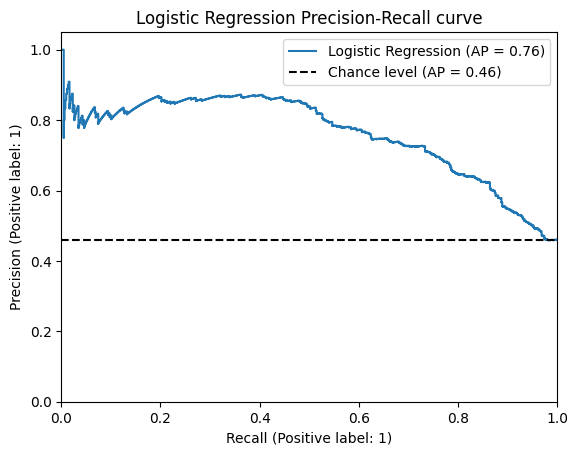

In [9]:
display = PrecisionRecallDisplay.from_estimator(
    base_lr,            # Trained model
    X_test,              # Test features
    y_test,              # True labels
    name="Logistic Regression",          # Name for legend
    plot_chance_level=True  # Automatically plots chance-level baseline
)

display.ax_.set_title("Logistic Regression Precision-Recall curve")
display.ax_.legend(loc='upper right')
display.ax_.set_xlim([0.0, 1.0])
display.ax_.set_ylim([0.0, 1.05])
plt.show()

### Additional

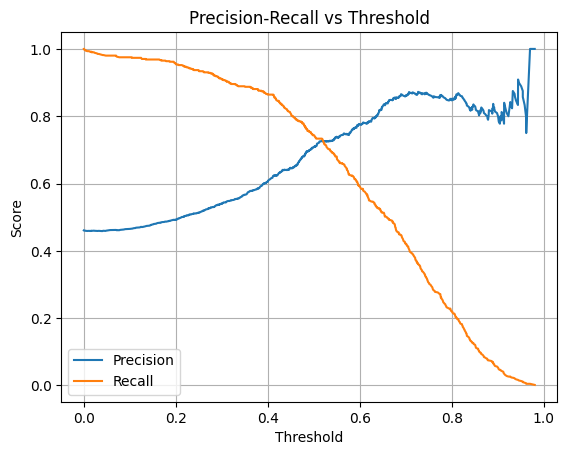

In [10]:
y_proba_tune = base_lr.predict_proba(X_test)[:, 1]       #Probabilities for class 1
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_tune)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.grid()
plt.legend()
plt.show()

In [11]:
# Apply custom threshold
y_proba_custom = (y_proba_tune >= 0.40).astype(int)
print(f'Classification Report: \n{classification_report(y_test, y_proba_custom, digits = 3)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0      0.820     0.521     0.637       707
           1      0.607     0.866     0.714       604

    accuracy                          0.680      1311
   macro avg      0.713     0.693     0.675      1311
weighted avg      0.722     0.680     0.672      1311


